# Stochastic Interest Rate Modelling and Prediction


Phase A : Data engineering and preprocessing 

Phase B : Base CIR Model implementation and calibration 

Phase C : Full yield curve construction from only 3M rate 

Phase D : Model extension using CIR++ method 

Phase E : Critical analysis 

## Mathematical Background of CIR

### The Stochastic Differential Equation

The dynamics of the short rate are governed by:

$$
dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t
$$

The model assumes that the interest rates are driven by two competing forces:
1. Mean Reversion: The first half of the equation, pulls the interest rate toward a normal long-term average theta. If rates spike too high, they get pulled down. If they drop too low, they get pulled up. The speed of this snap-back is controlled by kappa.
2. State-Dependent Volatility: The second half of the equation, represents the random daily market shocks. Crucially, this shock is multiplied by square root of short rate. This means if rates ever drop dangerously close to zero, the volatility shrinks as well—naturally preventing the rate from falling below zero.

**Feller Condition:** $2\kappa\theta \geq \sigma^2$. It guarantees that short rate stays strictly positive.


### Zero-Coupon Bond Pricing

$$
P = Ae^{-Br_t}
$$

Where the deterministic functions A and B are:

$$
\ln A = \frac{2\kappa\theta}{\sigma^2}
  \left[\ln(2\gamma) + \frac{(\kappa+\gamma)}{2}
        - \ln\!\bigl((\gamma+\kappa)(e^{\gamma}-1)+2\gamma\bigr)\right]
$$

$$
B = \frac{2(e^{\gamma}-1)}{(\gamma+\kappa)(e^{\gamma}-1)+2\gamma}
$$

On setting $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$.

**Yield for maturity:**

$$
y = \frac{B\,r_0 - \ln A}{\tau}
$$

Because of its structure, the CIR model is an Affine Yield Model. This means that the yield of a bond of any maturity is simply a linear function of that day's short rate. 
* The B factor defines how sensitive a long term bond is to changes in the current short-term rate.
* The log A factor acts as a built-in mathematical cushion (convexity adjustment). It accounts for the extra risk an investor takes by locking their money away for a long period of time.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize, differential_evolution
from scipy.stats import ncx2
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge

#For plotting graphs (Universal)
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize':(14,5),
    'font.size':11,
    'axes.titlesize':13,
    'axes.labelsize':11,
    'figure.dpi':100,
})

#To ensure results are reproducible
np.random.seed(42)

#Maturity mappings (column name to years to maturity) 
MATURITY_MAP={'ZC025YR':0.25,'ZC050YR':0.50,'ZC075YR':0.75,'ZC100YR':1.00,'ZC200YR':2.00,'ZC500YR':5.00,'ZC1000YR':10.00,'ZC2000YR':20.00,'ZC3000YR':30.00}
MATURITY_LABELS={'ZC025YR':'3M','ZC050YR':'6M','ZC075YR':'9M','ZC100YR':'1Y','ZC200YR':'2Y','ZC500YR':'5Y','ZC1000YR':'10Y','ZC2000YR':'20Y','ZC3000YR':'30Y'}

#DT is the fundamental time step used for integration, calibration, and simulation.
DT=1.0/252   # One trading day in years
print(f"dt={DT} year (1/252 trading days)")

dt=0.003968253968253968 yr (1/252 trading days)


In [ ]:
#CIR MODEL IMPLEMENTATION
class CIRModel:
    # Cox-Ingersoll-Ross (CIR) Interest Rate Model. Provides methods for zero-coupon bond pricing, yield curve construction and Maximum Likelihood Estimation (MLE) densities.

    #Model parameters
    def __init__(self,kappa,theta,sigma):
        self.kappa=float(kappa)
        self.theta=float(theta)
        self.sigma=float(sigma)

    #Helper function for gamma
    def _gamma(self):
        #Formula: gamma=sqrt(kappa^2+2*sigma^2)
        return np.sqrt(self.kappa*self.kappa+2.0*self.sigma*self.sigma)

    #Deterministic functions A and B
    def B(self,tau):
        #Sensitivity of bond log-price to the short rate.

        #Ensuring tau is treated as an array for vectorized calc.
        tau=np.atleast_1d(np.asarray(tau, dtype=np.float64))

        #Calculating gamma*tau as this term appears frequently
        gt=self._gamma()*tau
        res=np.empty_like(tau)

        #If gamma*tau is large, np.exp(gt) will cause a memory limit exceeded/overflow error, so we split the calculation into safe and big values to handle this
        safe=gt<=500
        big=gt>500

        #Limit of B as tau goes to infinity
        res[big]=2.0/(self._gamma()+self.kappa)

        #Standard Calculation
        #e^(gamma*tau)
        exp_gt=np.exp(gt[safe])

        #Denominator: (gamma + kappa)*(e^(gamma*tau)-1) + 2*gamma
        denom =(self._gamma()+self.kappa)*(exp_gt-1.0)+(2.0*self._gamma())

        #Final calculation for B on safe values
        res[safe]=2.0*(exp_gt-1.0)/denom

        return res[0] if res.size==1 else res

    def log_A(self, tau):
        #Log of the affine scaling factor in P

        # Calculate the power coefficient
        nu=2.0*self.kappa*self.theta/self.sigma**2

        #Ensure tau is an array (Same as done above for B)
        tau=np.atleast_1d(np.asarray(tau, dtype=np.float64))
        gt=self._gamma()*tau
        res=np.empty_like(tau)

        #Separate safe values from large values to prevent overflow
        safe=gt<=500
        big=gt>500

        #Large tau approximation: 
        # Instead of calculating log(infinity), we approximate
        res[big] = nu*(np.log(2.0*self._gamma())+(self.kappa+self._gamma())*tau[big]/2.0-np.log(self._gamma()+self.kappa)-self._gamma()*tau[big])

        #Standard calculation for normal maturities
        exp_gt=np.exp(gt[safe])
        denom=(self._gamma()+self.kappa)*(exp_gt-1.0)+2.0*self._gamma()

        #Final Calculation
        res[safe]=nu*(np.log(2.0*self._gamma())+(self.kappa+self._gamma())*tau[safe]/2.0-np.log(denom))

        return res[0] if res.size == 1 else res

    #Public API
    def bond_price(self,tau,r0):
        #Calculates P=A*exp(-B*r0)
        #Because we calculated log_A, we will use exp(log_A-B*r0)
        return np.exp(self.log_A(tau)-self.B(tau)*r0)

    def yield_curve(self,tau,r0):
        #Continuously compounded yield: y=(B*r0 -log_A)/tau
        #Add a small epsilon to tau to prevent any kind of division by zero
        tau_safe=np.maximum(tau,1e-8)
        return (self.B(tau_safe)*r0-self.log_A(tau_safe))/tau_safe

    def transition_logpdf(self,r_next,r_curr,dt):
        #CIR transition log-density for MLE

        #The transition density of the CIR model follows a chi square distribution.
        e_kdt=np.exp(-self.kappa*dt)

        #Calculate the scaling factor c
        c=2.0*self.kappa/(self.sigma**2*(1.0-e_kdt))

        #Calculate degrees of freedom d
        d=4.0*self.kappa*self.theta/self.sigma**2
        
        #Calculate the non-centrality parameter nc
        nc=2.0*c*np.asarray(r_curr)*e_kdt

        #Scale the target variable r_next
        x=2.0*c*np.asarray(r_next)
        
        try:
            #Calculate the log probability density using ncx2
            #Add np.log(2c) as the Jacobian adjustment for variable transformation
            ll=ncx2.logpdf(x,d,nc)+np.log(2.0*c)
            #If the calculation succeeds, return it, else return a highly negative penalty
            return np.where(np.isfinite(ll),ll,-1e10)
        except Exception:
            return np.full_like(x,-1e10,dtype=float)

    #Convenience properties
    @property
    def feller_ratio(self):
        #Calculates 2*kappa*theta/sigma^2
        return 2.0*self.kappa*self.theta/self.sigma**2

    @property
    def feller_satisfied(self):
        #Feller condition is satisfied if the ratio is greater than or equal to 1
        return self.feller_ratio >= 1.0

    @property
    def long_run_yield(self):
        #CIR yield as maturity (tau) tends to infinity
        return 2.0*self.kappa*self.theta/(self._gamma()+self.kappa)

    def __repr__(self):
        fc="OK" if self.feller_satisfied else "NOT OK"
        return (f"kappa={self.kappa:.4f}, theta={self.theta:.4f}, "
                f"sigma={self.sigma:.4f} with Feller={fc}")


#Example testing
print("For testing purpose only")
_m=CIRModel(kappa=0.5,theta=0.03,sigma=0.05)
_taus=np.array([0.25,0.5,1.0,2.0,5.0,10.0,20.0,30.0])
_r0=0.02

_y=_m.yield_curve(_taus,_r0)
_P=_m.bond_price(_taus,_r0)

print(f"Model param.:{_m}")
print(f"% Yields    :{np.round(_y*100,3)}")
print(f"Prices      :{np.round(_P,4)}")

For testing purpose only
Model param.:kappa=0.5000, theta=0.0300, sigma=0.0500 with Feller=OK
% Yields    :[2.06  2.115 2.212 2.366 2.627 2.792 2.888 2.92 ]
Prices      :[0.9949 0.9895 0.9781 0.9538 0.8769 0.7564 0.5613 0.4164]


## Phase A : Data Engineering and Preprocessing

### Dataset Characteristics

train_data.csv     :1,976 columns,9 yield maturities (3M–30Y)

test_data.csv      :495 columns, 5 maturities (3M–2Y)

test_data_3M.csv   :495 columns, 3M only (as input)

### Preprocessing Steps
To ensure stability, the raw data was passed through a strict preparation pipeline:

1. Standardization: Stripped all hidden leading and trailing whitespaces from column headers to prevent dictionary key errors.
2. Chronological Ordering: Converted date strings into proper datetime and sorted the dataset to maintain order.
3. Anomaly Detection: Passed the yields through a statistical Winsorization filter using an Interquartile Range threshold to catch and cap errors. Although no anomalies were found.
4. Quality Validation: Conducted a final cross check sweep. 

In [ ]:
#PHASE A: DATA LOADING and PREPROCESSING

def load_csv(path):
    #Load yield csv, strip column whitespace and sort by dates
    df=pd.read_csv(path)
    df.columns=df.columns.str.strip()
    df['Date']=pd.to_datetime(df['Date'])
    return df.sort_values('Date').reset_index(drop=True)

#Load datasets 
train_df=load_csv('train_data.csv')
test_full=load_csv('test_data.csv')
test_3m=load_csv('test_data_3M.csv')

#Identify yield columns and maturities
TRAIN_YIELD_COLS=[c for c in train_df.columns if c in MATURITY_MAP]
TEST_YIELD_COLS=[c for c in test_full.columns if c in MATURITY_MAP and c!='ZC025YR'] 
ALL_TEST_COLS=[c for c in test_full.columns if c in MATURITY_MAP]

TRAIN_TAUS=np.array([MATURITY_MAP[c] for c in TRAIN_YIELD_COLS])
TEST_TAUS=np.array([MATURITY_MAP[c] for c in TEST_YIELD_COLS])
TEST_LABELS=[MATURITY_LABELS[c] for c in TEST_YIELD_COLS]

#Outlier detection and winsorisation
def winsor(series,k=3.0):
    #Clips extreme values beyond k*IQR to prevent training instability
    #However, no outliers were detected so it is not needed
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR=Q3-Q1
    return series.clip(Q1-k*IQR,Q3+k*IQR)

#Apply winsorization to training data
for col in TRAIN_YIELD_COLS:
    train_df[col] = winsor(train_df[col])

#Summary stats. of training data
print("Yield Summary Statistics for training data")
summary = (train_df[TRAIN_YIELD_COLS] * 100).describe().round(3)
summary.columns = [MATURITY_LABELS[c] for c in TRAIN_YIELD_COLS]
print(summary.loc[['mean','std','min','25%','75%','max']].to_string())

#Full prediction maturities: 6m to 30y 
PRED_YIELD_COLS=['ZC050YR','ZC075YR','ZC100YR','ZC200YR',
                   'ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
PRED_TAUS=np.array([0.5,0.75,1.0,2.0,5.0,10.0,20.0,30.0])
PRED_LABELS =['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

Yield Summary Statistics for training data
         3M     6M     9M     1Y     2Y     5Y    10Y    20Y    30Y
mean  1.670  1.789  1.853  1.917  1.806  1.811  2.023  2.282  2.262
std   1.664  1.676  1.665  1.659  1.366  1.040  0.880  0.714  0.660
min   0.049  0.088  0.105  0.123  0.142  0.279  0.445  0.839  0.692
25%   0.462  0.519  0.545  0.573  0.590  0.957  1.445  1.774  1.790
75%   1.711  1.938  2.108  2.274  2.555  2.642  2.734  2.815  2.741
max   5.196  5.320  5.404  5.494  4.850  4.315  4.223  4.069  3.931


## Phase B: Exploratory Data Analysis

Before calibrating the CIR model, it is important to understand the yield curve data. This phase serves two primary objectives:

1. Justify the 1-Factor Model: We evaluate the cross-maturity correlation matrix. If yields across all maturities move highly in tandem, a 1-factor model like the base CIR is justified as a strong baseline.
2. Identify Regime Shifts: The basic CIR model inherently struggles to fit inverted yield curves (where short term rates exceed long term rates). By plotting the 30Y - 3M spread, we map out exact historical periods of curve inversion to find out where the base model will likely fail.

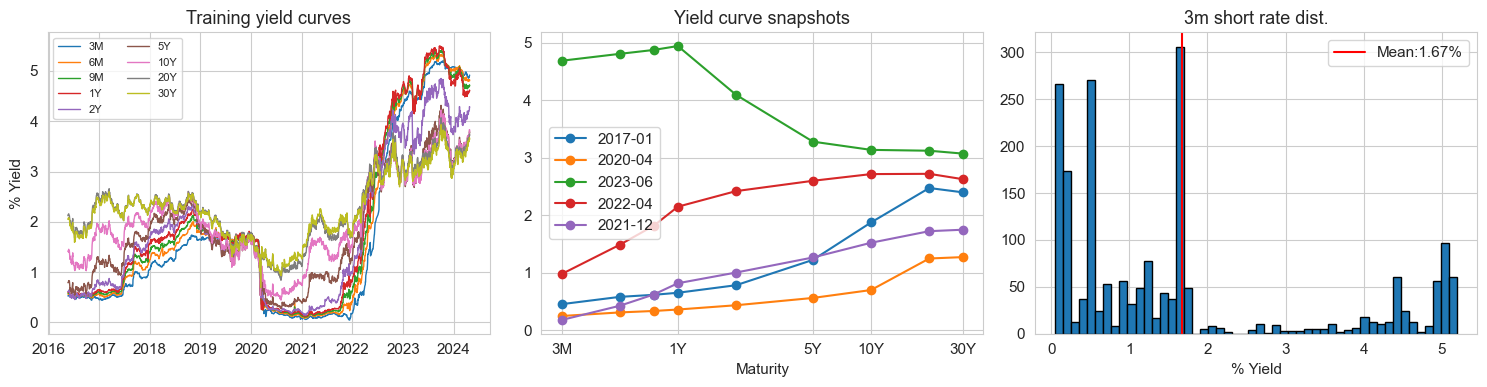

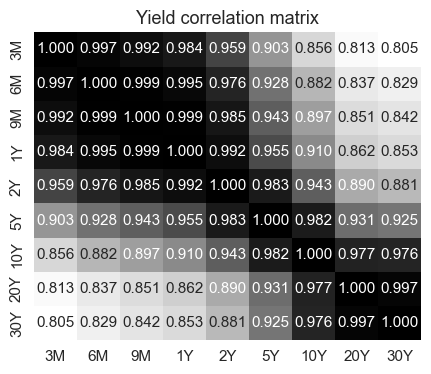

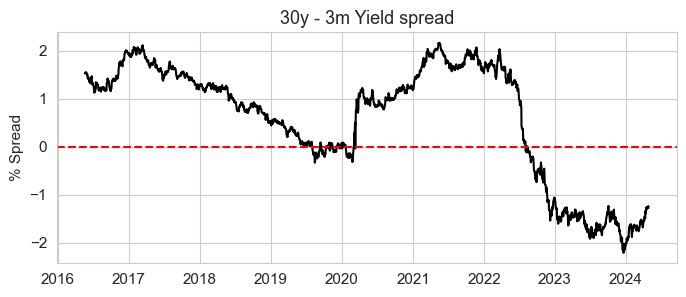

In [258]:
#PHASE B: EXPLORATORY DATA ANALYSIS

#Create a grid for our first set of charts
fig,axes=plt.subplots(1,3,figsize=(15,4))

#Plot 1: Historical time series (for all maturities)
for col in TRAIN_YIELD_COLS:
    axes[0].plot(train_df['Date'],train_df[col]*100,label=MATURITY_LABELS[col],lw=1)

axes[0].set_title('Training yield curves')
axes[0].set_ylabel('% Yield')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].legend(fontsize=8,ncol=2)

#Plot 2: Term structure snapshots (for yield curve shape) on random dates
snap_dates = ['2017-01-03','2020-04-01','2023-06-01','2022-04-09','2021-12-30']

for date in snap_dates:
    row=train_df[train_df['Date']>=pd.Timestamp(date)].iloc[0]
    exact_date=row['Date']
    axes[1].plot(TRAIN_TAUS, row[TRAIN_YIELD_COLS].values*100, marker='o', label=exact_date.strftime('%Y-%m'))

axes[1].set_xscale('log') 
axes[1].set_xticks([0.25,1,5,10,30])
axes[1].set_xticklabels(['3M','1Y','5Y','10Y','30Y'])
axes[1].set_title('Yield curve snapshots')
axes[1].set_xlabel('Maturity')
axes[1].legend()

#Plot 3: 3m short rate distribution
sr=train_df['ZC025YR']*100
axes[2].hist(sr, bins=50, edgecolor='black')
axes[2].axvline(sr.mean(),color='red',label=f'Mean:{sr.mean():.2f}%')
axes[2].set_title('3m short rate dist.')
axes[2].set_xlabel('% Yield')
axes[2].legend()
plt.tight_layout()
plt.show()

#Yield correlation matrix 
plt.figure(figsize=(5,4))
corr=train_df[TRAIN_YIELD_COLS].corr()
corr.columns=corr.index=[MATURITY_LABELS[c] for c in TRAIN_YIELD_COLS]
sns.heatmap(corr,annot=True,fmt='.3f',cmap='Greys',cbar=False)
plt.title('Yield correlation matrix')
plt.show()
# High correlation across the curve justifies the use of 1-factor model like CIR

plt.figure(figsize=(8,3))
spread=(train_df['ZC3000YR']-train_df['ZC025YR'])*100
plt.plot(train_df['Date'],spread,color='black',lw=1.5)
plt.axhline(0,color='red',linestyle='--')
plt.title('30y - 3m Yield spread')
plt.ylabel('% Spread')
plt.show()
# Spread which is below 0 indicates an "Inverted Yield Curve", which is difficult to predict for CIR model.

## Model Calibration Strategy

To make the CIR model work, we need to find the best settings for the parameters using training data. We test three different ways to train the model:

### 1. Ordinary / Generalized least squares (OLS / GLS)
* How it works: It looks only at how the 3-Month rate changes over time.
* Pros: It is computationally fast and uses a straightforward math formula.
* Cons: It relies on an approximation that breaks down when markets get chaotic. It is too rigid to handle extreme, sudden spikes in volatility (like the COVID-19 crash visible in the graph above).

### 2. Maximum likelihood estimation (MLE)
* How it works: It also looks only at how the 3-Month rate changes over time.
* Pros: It is highly accurate for day to day changes. It uses the exact probability math of the CIR model, avoiding the breakdown issues of the OLS method.
* Cons: Because it only focuses on the 3-Month rate, it is completely blind to the rest of the market. It fails to understand how long-term bonds are priced.

### 3. Cross sectional optimization (Full Curve)
* How it works: It looks at the entire yield curve (3m to 30y) all at once.
* Pros: Instead of just looking at rates, this method tries to minimize prediction errors across all bond maturities simultaneously. By forcing the model to pay attention to 30 Year bonds, it successfully figures out true long-term market averages.

### Primary Calibration Choice: Cross-Sectional
We select Cross-Sectional Optimization as our final base model. Since the goal of this project is to predict the missing pieces of the yield curve (6M–2Y), training the model to minimize errors across the whole curve is the best choice.

In [ ]:
#CALIBRATION METHODS

def calibrate_ols(rates,dt=DT):
    rates=np.asarray(rates)
    r_curr=rates[:-1] 
    r_next=rates[1:]

    #Filter out rates that are close to zero to prevent division by zero
    valid=r_curr>1e-7
    rc,rn=r_curr[valid], r_next[valid]
    sqrc=np.sqrt(rc)

    #Transform variables for linear regression
    #Y = (rn-rc)/sqrt(r)
    Y=(rn-rc)/sqrc
    X=np.column_stack([dt/sqrc,-dt*sqrc])

    #Run the least squares optimization
    beta,_,_,_=np.linalg.lstsq(X,Y,rcond=None)

    #Extract parameters
    kappa=max(beta[1],1e-5)
    theta=max(beta[0]/kappa,1e-5)
    sigma=max(float(np.std(Y-X@beta)),1e-5)

    return dict(kappa=kappa,theta=theta,sigma=sigma,method='OLS')

def calibrate_mle(rates,dt=DT,init=None):
    #Time-Series Calibration: Rigorous optimization using the exact  non-central chi-squared transition density of the CIR model.
    rates =np.asarray(rates)
    r_curr=rates[:-1]
    r_next=rates[1:]

    # Filter out extreme near zeroes
    valid=(r_curr>1e-7)&(r_next>1e-7)
    rc,rn=r_curr[valid],r_next[valid]

    #If no initial guess is provided, run the fast OLS method to get a starting point
    if init is None:
        ols=calibrate_ols(rates, dt)
        init=[ols['kappa'],ols['theta'],ols['sigma']]

    def loglik(params):
        kappa,theta,sigma=params

        #Immediate penalty if the optimizer tries negative numbers
        if kappa<=0 or theta<=0 or sigma<=0:
            return 1e10
        
        #Calculate the mathematical terms for the non-central chi-squared distribution
        e_kdt=np.exp(-kappa*dt)
        c=2.0*kappa/((sigma**2)*(1.0-e_kdt))
        d=4.0*kappa*theta/sigma**2
        nc=2.0*c*rc*e_kdt
        x=2.0*c*rn

        try:
            #Calculate the sum of the exact log-likelihoods for every day in the dataset
            ll = float(ncx2.logpdf(x,d,nc).sum()) + np.log(2.0*c)*len(x)
            return -ll if np.isfinite(ll) else 1e10
        except Exception:
            return 1e10

    #Optimization bounds to prevent parameters from entering physically unrealistic ranges
    bounds=[(1e-4,15.0),(1e-5,0.30),(1e-4,1.0)]
    #Try multiple starting points to ensure we don't get stuck in a local minimum
    starts=[init,[0.10,rc.mean(),0.01],[1.50,rc.mean(),0.08]]
    best_val,best_x=np.inf,init

    for sp in starts:
        res = minimize(loglik,sp,method='L-BFGS-B',bounds=bounds, 
                       options={'maxiter':5000})
        if res.success and res.fun<best_val:
            best_val,best_x =res.fun,res.x

    return dict(kappa=best_x[0],theta=best_x[1],sigma=best_x[2],loglik=-best_val,method='MLE')

def calibrate_cross_sectional(df,yield_cols,taus,r0_col='ZC025YR',subsample=3,feller_penalty=1e5,weights=None):
    #Term-Structure Calibration: Minimizes the Mean Squared Error (MSE) between historical and model-predicted yield curves.
    
    #Setup weighting scheme (default to equal weights if none provided)
    if weights is None:
        weights = np.ones(len(taus))
    weights = np.asarray(weights, dtype=float)
    weights /= weights.sum()

    #Extract and subsample data to speed up optimization
    r0_s = df[r0_col].values[::subsample]
    Y_s = df[yield_cols].values[::subsample]

    def objective(params):
        kappa, theta, sigma = params
        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return 1e10
        
        #Heavily penalize parameters that violate the feller condition
        feller_viol=max(0.0,sigma**2 -2.0*kappa*theta)
        penalty=feller_penalty*feller_viol**2

        try:
            #Predict the whole yield curve for every short rate
            model=CIRModel(kappa,theta,sigma)
            B=np.atleast_1d(model.B(taus))
            logA=np.atleast_1d(model.log_A(taus))
            
            Y_hat=(B[None,:]*r0_s[:,None]-logA[None,:])/taus[None,:]
            if not np.all(np.isfinite(Y_hat)):
                return 1e10
            
            #Return the weighted mean squared error+feller penalty
            return float(np.mean(np.dot((Y_s-Y_hat)**2,weights)))+penalty
        except Exception:
            return 1e10

    #Physically constrained bounds (prevents Feller condition violation)
    bounds=[(0.10,5.0),(0.010,0.10),(0.005,0.18)]

    #Differential Evolution (global search to avoid local minima)
    de = differential_evolution(
        objective,bounds,seed=42,maxiter=600,tol=1e-11,
        workers=1,polish=True,mutation=(0.5, 1.5),
        recombination=0.9, popsize=22
    )

    #L-BFGS-B (local gradient descent to perfectly hone in on minima)
    res=minimize(
        objective,de.x,method='L-BFGS-B',bounds=bounds,
        options={'maxiter':5000,'ftol':1e-14}
    )

    return dict(kappa=res.x[0],theta=res.x[1],sigma=res.x[2],loss=res.fun,method='CrossSectional')

In [260]:
#RUN ALL THREE CALIBRATIONS and COMPARE
short_rate_train=train_df['ZC025YR'].values

#Calibration 1: OLS
print("Calibration 1: OLS/GLS")
ols=calibrate_ols(short_rate_train, dt=DT)
print(f"kappa={ols['kappa']:.5f} | theta={ols['theta']*100:.4f}% | sigma={ols['sigma']:.5f}")

#Calibration 2: MLE
print("Calibration 2: MLE")
mle=calibrate_mle(short_rate_train,dt=DT)
print(f"kappa={mle['kappa']:.5f} | theta={mle['theta']*100:.4f}% | sigma={mle['sigma']:.5f}")

#Calibration 3: Cross-Sectional
print("Calibration 3: Cross-Sec.")
cs=calibrate_cross_sectional(train_df,TRAIN_YIELD_COLS,TRAIN_TAUS)
print(f"kappa={cs['kappa']:.5f} | theta={cs['theta']*100:.4f}% | sigma={cs['sigma']:.5f}")

#Build model objects
m_ols=CIRModel(ols['kappa'],ols['theta'],ols['sigma'])
m_mle=CIRModel(mle['kappa'],mle['theta'],mle['sigma'])
m_cs=CIRModel(cs['kappa'],cs['theta'],cs['sigma'])

#Summary table
print("\nCalibration summary table")
print(f"{'Method':<24} {'kappa':>7} {'theta(%)':>9} {'sigma':>7} "
      f"{'F.Ratio':>8} {'Feller':>7} ")
for name, m in [('OLS/GLS',m_ols),('MLE',m_mle),('CrossSec',m_cs)]:
    print(f"{name:<24} {m.kappa:>7.5f} {m.theta*100:>9.4f} {m.sigma:>7.5f} "
          f"{m.feller_ratio:>8.3f} {'OK' if m.feller_satisfied else 'NOT OK':>4} ")

#Final model selection
cs=calibrate_cross_sectional(train_df,TRAIN_YIELD_COLS,TRAIN_TAUS)
model_cs=CIRModel(cs['kappa'],cs['theta'],cs['sigma'])
print("\nModel Selected: Cross-Sectional")
print(f"   Parameters  : kappa={m_cs.kappa:.5f} | theta={m_cs.theta*100:.4f}% | sigma={m_cs.sigma:.5f}")
print(f"   Limit Yield : {m_cs.long_run_yield * 100:.4f}%")
print(f"  Feller Ratio : {m_cs.feller_ratio:.3f}")

Calibration 1: OLS/GLS
kappa=0.00001 | theta=13484.3935% | sigma=0.00260
Calibration 2: MLE
kappa=0.00676 | theta=30.0000% | sigma=0.04258
Calibration 3: Cross-Sec.
kappa=0.16564 | theta=2.4437% | sigma=0.00500

Calibration summary table
Method                     kappa  theta(%)   sigma  F.Ratio  Feller 
OLS/GLS                  0.00001 13484.3935 0.00260  398.094   OK 
MLE                      0.00676   30.0000 0.04258    2.237   OK 
CrossSec                 0.16564    2.4437 0.00500  323.830   OK 

Model Selected: Cross-Sectional
   Parameters  : kappa=0.16564 | theta=2.4437% | sigma=0.00500
   Limit Yield : 2.4426%
  Feller Ratio : 323.830


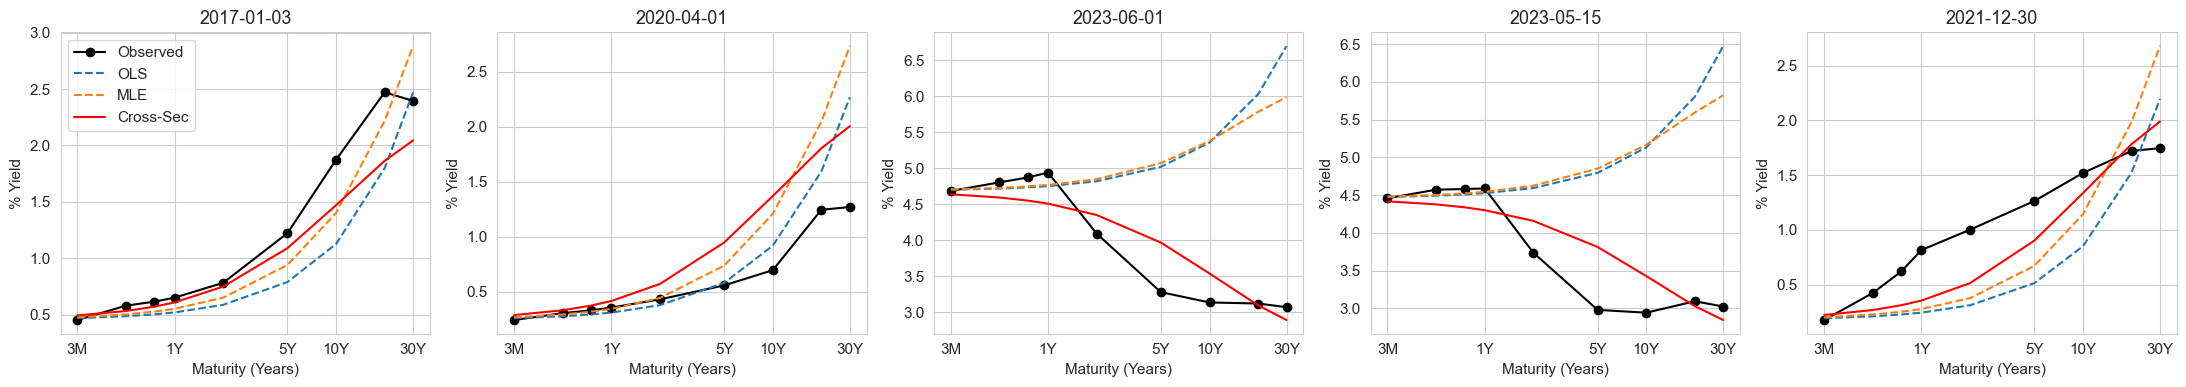

Overall In-sample R^2: 0.92300

R^2 Per Maturity:
   3M: 0.99949
   6M: 0.98887
   9M: 0.97385
   1Y: 0.95147
   2Y: 0.91268
   5Y: 0.77047
  10Y: 0.72542
  20Y: 0.63463
  30Y: 0.55544


In [208]:
#CALIBRATION QUALITY (In-sample)

#Curve fit checks
snap_dates=['2017-01-03','2020-04-01','2023-06-01','2023-05-15','2021-12-30']
fig,axes=plt.subplots(1,5,figsize=(22,4))

for idx,d_str in enumerate(snap_dates):
    ax=axes[idx]
    
    #Extract exact data
    row=train_df[train_df['Date']>=pd.Timestamp(d_str)].iloc[0]
    r0,y_obs=row['ZC025YR'],row[TRAIN_YIELD_COLS].values*100
    
    #Get predictions from all three models based on r0
    y_ols=m_ols.yield_curve(TRAIN_TAUS,r0)*100
    y_mle=m_mle.yield_curve(TRAIN_TAUS,r0)*100
    y_cs=m_cs.yield_curve(TRAIN_TAUS,r0)*100
    
    #Plot the results
    ax.plot(TRAIN_TAUS,y_obs,label='Observed',marker='o',color='black')
    ax.plot(TRAIN_TAUS,y_ols,label='OLS',linestyle='--')
    ax.plot(TRAIN_TAUS,y_mle,label='MLE',linestyle='--')
    ax.plot(TRAIN_TAUS,y_cs,label='Cross-Sec',color='red')
    
    #Formatting
    ax.set_xscale('log')
    ax.set_xticks([0.25,1,5,10,30])
    ax.set_xticklabels(['3M','1Y','5Y','10Y','30Y'])
    ax.set_title(row['Date'].strftime('%Y-%m-%d'))
    ax.set_xlabel('Maturity (Years)')
    ax.set_ylabel('% Yield')
    if idx==0:
        ax.legend()

plt.tight_layout()
plt.show()

#In-sample R^2 score

#Extract terms, inputs, and actual target yields
B_tr=np.atleast_1d(m_cs.B(TRAIN_TAUS))
logA_tr=np.atleast_1d(m_cs.log_A(TRAIN_TAUS))
r0_tr=train_df['ZC025YR'].values
Y_obs=train_df[TRAIN_YIELD_COLS].values

#Predict all training yields instantly using matrix multiplication
Y_pred=(B_tr[None,:]*r0_tr[:,None]-logA_tr[None,:])/TRAIN_TAUS[None,:]

print(f"Overall In-sample R^2: {r2_score(Y_obs.ravel(), Y_pred.ravel()):.5f}\n")
print("R^2 Per Maturity:")
for j, col in enumerate(TRAIN_YIELD_COLS):
    r2_val=r2_score(Y_obs[:, j],Y_pred[:, j])
    print(f"  {MATURITY_LABELS[col]:>3}: {r2_val:.5f}")

## Phase C: Out of sample prediction

### Objective
To evaluate the predictive power and out of sample robustness of our chosen baseline model (Cross-Sectional CIR). We want to test if the parameters learned from the data hold up when forced to reconstruct the yield curve using testing information.

### Protocol
* **The Input:** For each day in the unseen test dataset, the model is strictly blind to the broader market. It is provided only with that day's 3-Month short rate.
* **The Mechanism:** The model applies the closed-form affine yield formula, relying purely on the structural parameters locked in after training
* **The Output:** Based on the 3-Month rate, the model must extrapolate and reconstruct the yields for all target maturities.

### Hypothesis
Because this prediction relies completely on the rigid mathematical structure of a 1-factor model, we expect it to perform reasonably well during "normal" market conditions, but struggle during regime shifts or yield curve inversions.

In [261]:
#PHASE C: Prediction

def predict_yield_curve(model,r0_series,taus):
    """Vectorized yield-curve reconstruction."""
    r0=np.asarray(r0_series,dtype=float)
    t=np.asarray(taus,dtype=float)
    
    #Extract deterministic affine terms
    B=np.atleast_1d(model.B(t))      
    logA=np.atleast_1d(model.log_A(t))  

    #y = (B*r0 - logA) / tau
    return (B[None,:]*r0[:,None]-logA[None,:])/t[None,:]

def evaluate_predictions(actual, predicted, mat_labels):
    """Calculates R², RMSE, and MAE for predictions."""
    results = {}
    
    #Calculate metrics for individual maturities
    for j, lbl in enumerate(mat_labels):
        act, pred = actual[:, j], predicted[:, j]
        results[lbl]={'R2':r2_score(act,pred),'RMSE':np.sqrt(mean_squared_error(act,pred)),'MAE':mean_absolute_error(act,pred)}
        
    #Calculate overall metrics across the whole surface
    results['OVERALL']={'R2': r2_score(actual.ravel(), predicted.ravel()),'RMSE': np.sqrt(mean_squared_error(actual.ravel(), predicted.ravel()))}
    
    return results

#Prepare out of Sample Test Data
r0_test = test_3m['ZC025YR'].values        
Y_actual = test_full[TEST_YIELD_COLS].values

#Find which columns in our prediction match the required test targets
eval_idx = [list(PRED_TAUS).index(t) for t in TEST_TAUS]

#Run Predictions
#Cross-Sectional (Primary Model)
Y_pred_cs = predict_yield_curve(m_cs, r0_test, PRED_TAUS)[:, eval_idx]
metrics_cs = evaluate_predictions(Y_actual, Y_pred_cs, TEST_LABELS)

#OLS and MLE
Y_pred_ols = predict_yield_curve(m_ols, r0_test, PRED_TAUS)[:, eval_idx]
Y_pred_mle = predict_yield_curve(m_mle, r0_test, PRED_TAUS)[:, eval_idx]

#Calculate Overall R2 for OLS and MLE
r2_ols = r2_score(Y_actual.ravel(), Y_pred_ols.ravel())
r2_mle = r2_score(Y_actual.ravel(), Y_pred_mle.ravel())

#Summary
print("Out of Sample Results")
print(f"OLS Overall R2              :{r2_ols:>8.4f}")
print(f"MLE Overall R2              :{r2_mle:>8.4f}")
print(f"Cross-Sectional R2 (Primary):{metrics_cs['OVERALL']['R2']:>8.4f}")


Out of Sample Results
OLS Overall R2              :  0.7481
MLE Overall R2              :  0.7286
Cross-Sectional R2 (Primary):  0.8929


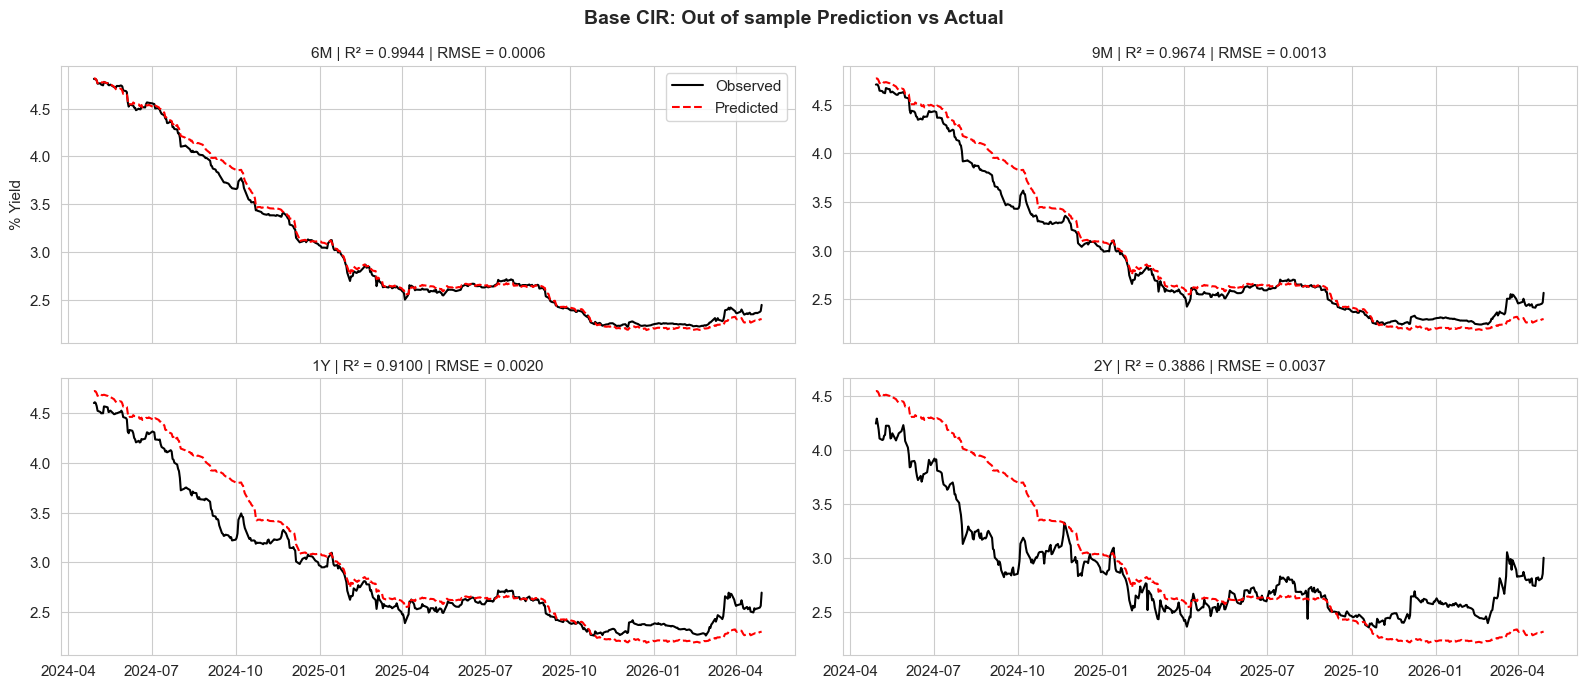

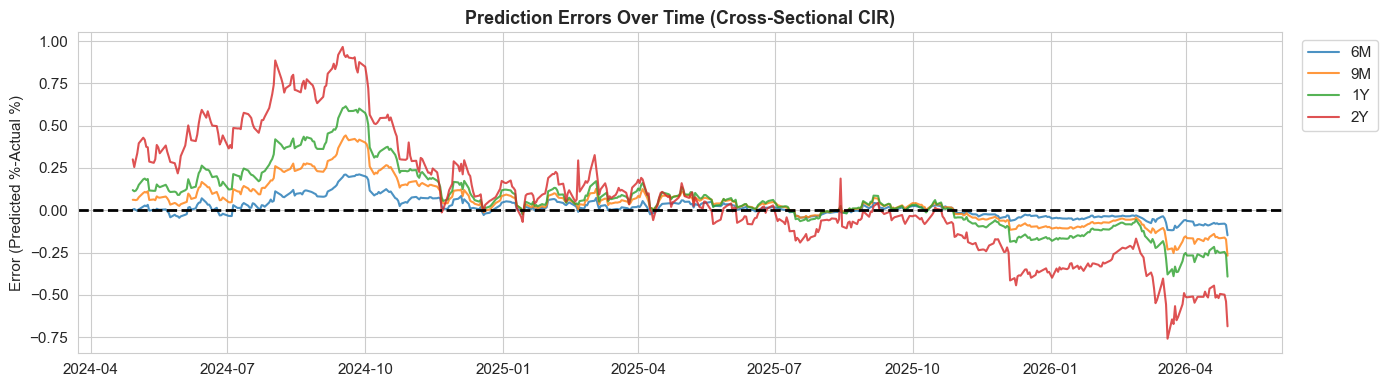

In [ ]:
#Prediction Visualisation
test_dates = test_full['Date']

#Time series comparison (Predicted vs Actual)
fig,axes=plt.subplots(2,2,figsize=(16,7),sharex=True)

for j,(lbl,ax) in enumerate(zip(TEST_LABELS,axes.ravel())):
    #Converting yields to percentages for plotting
    act = Y_actual[:, j]*100
    pred = Y_pred_cs[:, j]*100
    
    ax.plot(test_dates,act,color='black',lw=1.5,label='Observed')
    ax.plot(test_dates,pred,color='red',ls='--',lw=1.5,label='Predicted')
    
    #Extract metrics
    m=metrics_cs[lbl]
    ax.set_title(f"{lbl} | R² = {m['R2']:.4f} | RMSE = {m['RMSE']:.4f}",fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    if j==0: 
        ax.set_ylabel('% Yield')
        ax.legend()

plt.suptitle('Base CIR: Out of sample Prediction vs Actual',fontweight='bold',fontsize=14)
plt.tight_layout()
plt.show()

#Errors over time (Line plot)
plt.figure(figsize=(14, 4))

for j, lbl in enumerate(TEST_LABELS):
    # Plot errors in percentage
    plt.plot(test_dates,(Y_pred_cs[:, j]-Y_actual[:, j])*100,alpha=0.8,lw=1.5,label=lbl)

plt.axhline(0,color='black',ls='--',lw=2)
plt.title('Prediction Errors Over Time (Cross-Sectional CIR)',fontweight='bold')
plt.ylabel('Error (Predicted %-Actual %)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Phase D: Extending to CIR++ 

The standard CIR model is good at guaranteeing that interest rates never drop below zero. However, because it relies on just a single factor (the 3-Month rate), it is too rigid to predict the 30-year yield curve, especially when the market acts strangely (like during yield curve inversions).

The CIR++ extension fixes this by adding a correction term to fix the errors made by the base model. Our final predicted yield becomes:

$$
y = \frac{B \cdot r_0 - \ln A}{\tau} + \varphi
$$

### How we upgraded the model
Instead of using basic math to find the correction term, we built a CIR++ framework. We trained a Ridge Regression model to learn from the base model's mistakes. 

Here are the four major ways our model upgrades the standard approach:

* **Predicting the Full Curve:** While standard models only try to fix short-term predictions, our ML layer is built to predict the entire curve, all the way out to 30 years, based on the 3 Month rate.
* **Smarter Features:** Example: We feed it the exact gap between today's rate and the long-term average, helping the algorithm understand when the market is stretched too far.
* **Built-in Safety Rails:** To prevent the machine learning model from just memorizing, we use a Ridge penalty. This forces the algorithm to find the smoothest, most reliable correction for every single bond maturity.

In [ ]:
#PHASE D: CIR++ FULL YIELD CURVE
class CIRPlusPlus:
    #CIR++ framework utilizies Ridge Regression to correct base model pricing errors.

    # Alpha Schedule (Regularization)
    ALPHA_SCHEDULE={
        0.5:5000.,0.75:5000.,1.0:5000., # Short end: Base CIR is accurate
        2.0:0.10,5.0:0.10,10.0:0.50,    # Middle: Moderate correction
        20.0:1.00,30.0:2.00               # Long end: Conservative correction
    }  

    def __init__(self,cir_model):
        self.cir=cir_model
        self.theta=cir_model.theta # The long-term mean from Phase B
        self.ridges={}
        self.is_fitted=False

    #Feature Engineering
    def _features(self,r0,tau):
        #Builds maturity specific feature matrices
        r0=np.asarray(r0)
        dev=r0-self.theta
        
        return np.column_stack([np.ones_like(r0),r0,r0**2, dev])

    #Training 
    def fit(self,r0_train,Y_obs_train,train_taus):
        #Trains Ridge regression on CIR errors.
        r0_train,train_taus=np.asarray(r0_train),np.asarray(train_taus)
        
        #Ask Base CIR for its structural predictions and calculate the residuals (errors)
        B=np.atleast_1d(self.cir.B(train_taus))
        logA=np.atleast_1d(self.cir.log_A(train_taus))
        Y_base=(B[None, :]*r0_train[:, None]-logA[None, :])/train_taus[None, :]
        residuals=Y_obs_train-Y_base
        
        #Train a specific Ridge model for every maturity
        for tau, alpha in self.ALPHA_SCHEDULE.items():
            if tau not in train_taus:continue
            
            X=self._features(r0_train,tau)
            y_res=residuals[:,list(train_taus).index(tau)]
            
            #Standard fit across all days equally
            self.ridges[tau]=Ridge(alpha=alpha,fit_intercept=False).fit(X,y_res)

        self.is_fitted=True
        return self

    #Prediction
    def predict(self, r0_test, taus):
        #Reconstructs the full yield curve:Base CIR+Correction Term
        r0_test,taus=np.asarray(r0_test),np.asarray(taus)
        
        #Base CIR structural math
        B=np.atleast_1d(self.cir.B(taus))
        logA=np.atleast_1d(self.cir.log_A(taus))
        Y_pp=(B[None,:]*r0_test[:,None]-logA[None,:])/taus[None,:]
        
        #Add the dynamic correction term 
        for j, tau in enumerate(taus):
            closest_tau=min(self.ridges.keys(),key=lambda k:abs(k-tau))
            X=self._features(r0_test,closest_tau)
            Y_pp[:, j]+=self.ridges[closest_tau].predict(X)
            
        return Y_pp

#Train the CIR++ Model
r0_train_arr=train_df['ZC025YR'].values
Y_obs_train_all=train_df[TRAIN_YIELD_COLS].values

#Initialize and train using the standard model
cir_pp = CIRPlusPlus(m_cs)
cir_pp.fit(r0_train_arr, Y_obs_train_all,TRAIN_TAUS)

#Predict all maturities using both models
Y_pp_train=cir_pp.predict(r0_train_arr,PRED_TAUS)

B_base,logA_base=np.atleast_1d(m_cs.B(PRED_TAUS)),np.atleast_1d(m_cs.log_A(PRED_TAUS))
Y_base_train=(B_base[None, :]*r0_train_arr[:, None]-logA_base[None, :])/PRED_TAUS[None, :]

#Print In-sample comparison
print(f"\n{'Maturity':<10} {'Base CIR R2':>12} {'CIR++ R2':>12}  {'Test Set Status':>20}")

pred_tr_idx=[list(TRAIN_TAUS).index(t) for t in PRED_TAUS]
for j, (lbl, tau) in enumerate(zip(PRED_LABELS,PRED_TAUS)):
    y_actual=Y_obs_train_all[:, pred_tr_idx[j]]
    r2_base=r2_score(y_actual, Y_base_train[:, j])
    r2_plus=r2_score(y_actual, Y_pp_train[:, j])
    status="Target" if tau in TEST_TAUS else "Train"
    
    print(f"{lbl:<10} {r2_base:>12.4f} {r2_plus:>12.4f}  {status:>20}")


Maturity    Base CIR R2     CIR++ R2       Test Set Status
6M               0.9889       0.9902                Target
9M               0.9738       0.9771                Target
1Y               0.9515       0.9577                Target
2Y               0.9127       0.9190                Target
5Y               0.7705       0.8152                 Train
10Y              0.7254       0.7319                 Train
20Y              0.6346       0.6568                 Train
30Y              0.5554       0.6099                 Train


OUT-OF-SAMPLE R2 COMPARISON: Base CIR vs CIR++

 OVERALL Base: 0.8929 | CIR++: 0.9025 | Gain: +0.0097


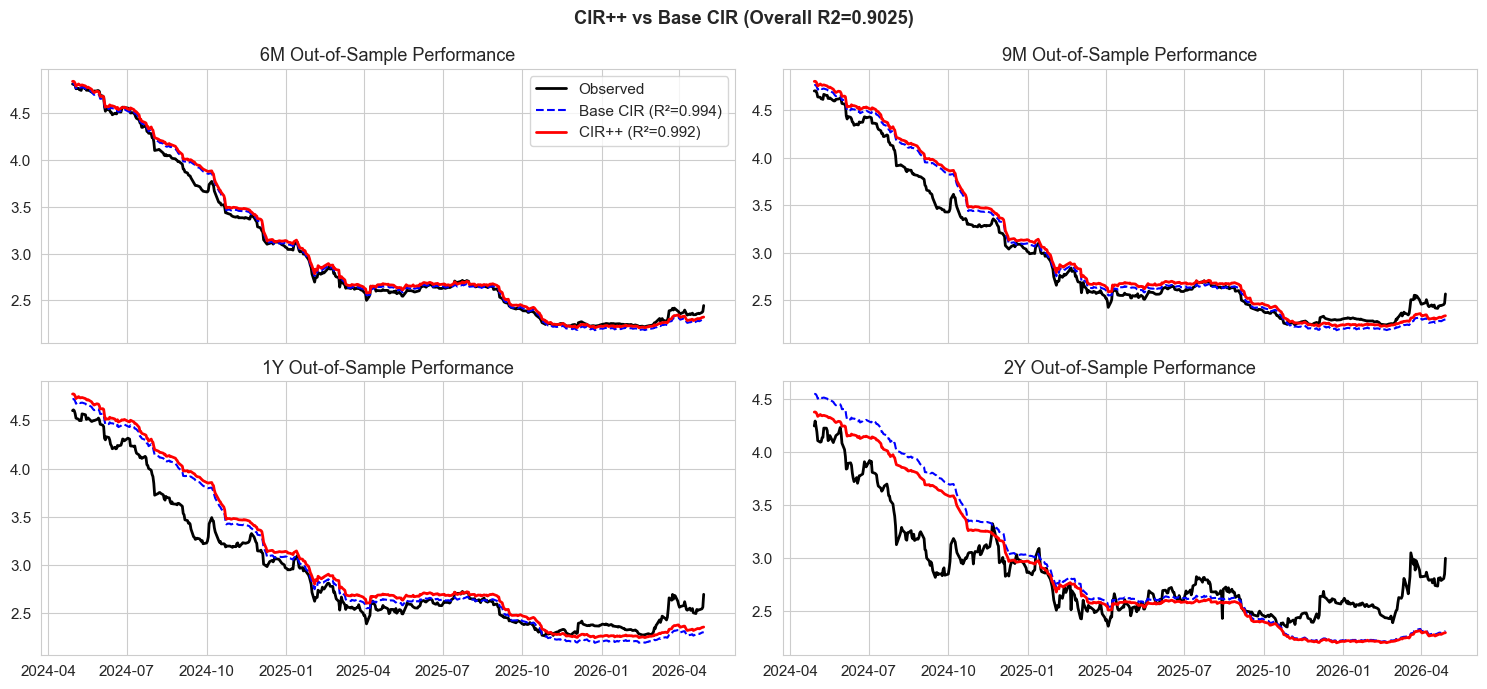

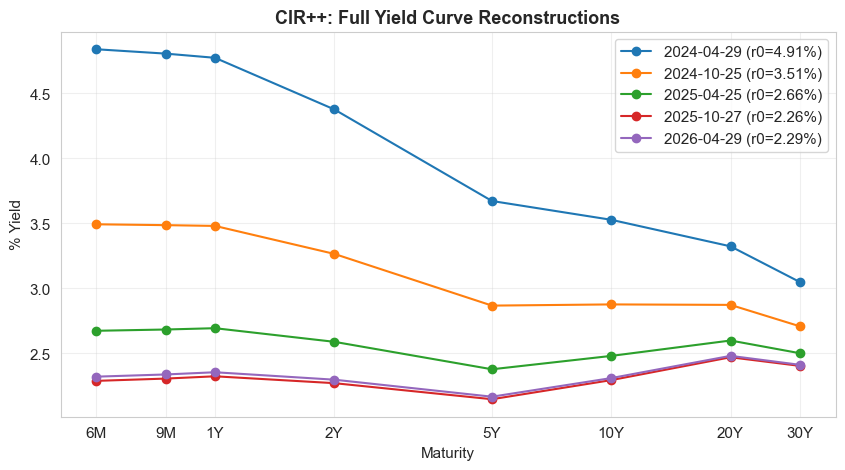

In [ ]:
#CIR++: OUT OF SAMPLE EVAL.

#Predict and slice test targets (6M-2Y)
Y_pred_pp_full=cir_pp.predict(r0_test,PRED_TAUS)
Y_pred_pp_eval=Y_pred_pp_full[:,[list(PRED_TAUS).index(t) for t in TEST_TAUS]]

#Evaluation of Base CIR vs CIR++
metrics_pp=evaluate_predictions(Y_actual,Y_pred_pp_eval,TEST_LABELS)

r2_ov_base=metrics_cs['OVERALL']['R2']
r2_ov_plus=metrics_pp['OVERALL']['R2']

print("OUT-OF-SAMPLE R2 COMPARISON: Base CIR vs CIR++")
print(f"\n OVERALL Base: {r2_ov_base:.4f} | CIR++: {r2_ov_plus:.4f} | Gain: {(r2_ov_plus - r2_ov_base):+.4f}")

#Time Series Comparison (Base vs CIR++)
fig, axes=plt.subplots(2,2,figsize=(15,7),sharex=True)

for j, (lbl, ax) in enumerate(zip(TEST_LABELS,axes.ravel())):
    act,p_base,p_plus=Y_actual[:, j]*100,Y_pred_cs[:, j]*100,Y_pred_pp_eval[:, j]*100
    
    ax.plot(test_dates,act,lw=2,color='black',label='Observed')
    ax.plot(test_dates,p_base,lw=1.5,color='blue',ls='--',label=f'Base CIR (R²={metrics_cs[lbl]["R2"]:.3f})')
    ax.plot(test_dates,p_plus,lw=2,color='red',label=f'CIR++ (R²={metrics_pp[lbl]["R2"]:.3f})')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_title(f'{lbl} Out-of-Sample Performance')
    if j == 0: ax.legend()

plt.suptitle(f'CIR++ vs Base CIR (Overall R2={r2_ov_plus:.4f})',fontweight='bold')
plt.tight_layout()
plt.show()

#Full Yield Curve Reconstruction :3M - 30Y
plt.figure(figsize=(10, 5))

# Pick 5 evenly spaced dates from the test set for curve construction
for ti in np.linspace(0,len(test_dates)-1,5,dtype=int):
    r0,d_str= r0_test[ti],test_dates.iloc[ti].strftime('%Y-%m-%d')
    plt.plot(PRED_TAUS,Y_pred_pp_full[ti]*100,marker='o',label=f'{d_str} (r0={r0*100:.2f}%)')

plt.xscale('log')
plt.xticks([0.5,0.75,1,2,5,10,20,30], ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y'])
plt.title('CIR++: Full Yield Curve Reconstructions',fontweight='bold')
plt.xlabel('Maturity')
plt.ylabel('% Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

FINAL TEST DAY YIELD CURVE
Date: 2026-04-29 | 3M Input Rate: 2.29%

 Maturity       Base CIR        CIR++
 3M               2.293%       2.318%
 6M               2.297%       2.321%
 9M               2.299%       2.338%
 1Y               2.302%       2.355%
 2Y               2.313%       2.298%
 5Y               2.339%       2.167%
 10Y              2.368%       2.310%
 20Y              2.398%       2.481%
 30Y              2.412%       2.412%


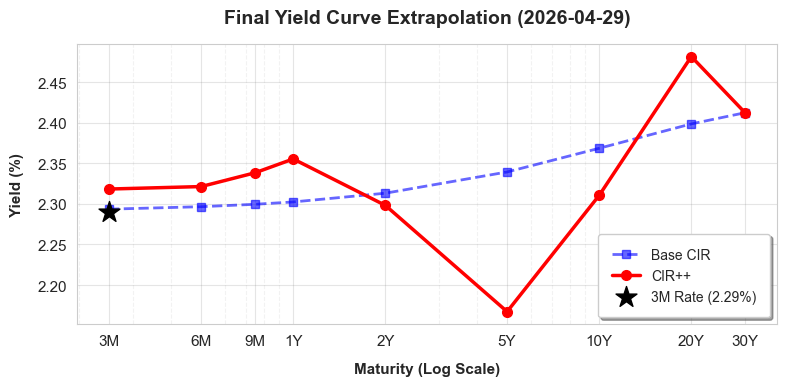

In [ ]:
#PHASE E: Model Diagnostics and Cross checking

#Final Curve Output
print("FINAL TEST DAY YIELD CURVE")

r0_final,final_date=r0_test[-1],test_full['Date'].iloc[-1].strftime('%Y-%m-%d')
taus=np.array([0.25,0.5,0.75,1.0,2.0,5.0,10.0,20.0,30.0])
lbls=['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

y_base=m_cs.yield_curve(taus,r0_final)*100
y_plus=cir_pp.predict(np.array([r0_final]),taus)[0]*100

print(f"Date: {final_date} | 3M Input Rate: {r0_final*100:.2f}%\n")
print(f" {'Maturity':<10} {'Base CIR':>12} {'CIR++':>12}")
for i in range(len(taus)):
    print(f" {lbls[i]:<10} {y_base[i]:>11.3f}% {y_plus[i]:>11.3f}%")

#Visualizing the Final Constructed Yield Curve
plt.figure(figsize=(8, 4))

#Plot Base CIR
plt.plot(taus, y_base, color='blue', linestyle='--', linewidth=2, 
         marker='s', markersize=6, alpha=0.6, label='Base CIR')

#Plot CIR++
plt.plot(taus, y_plus, color='red', linewidth=2.5, 
         marker='o', markersize=7, label='CIR++')

#Highlight the starting 3M Rate
plt.scatter([0.25], [r0_final * 100], color='black', marker='*', s=250, 
            zorder=5, label=f'3M Rate ({r0_final*100:.2f}%)')

plt.xscale('log')
plt.xticks(taus, lbls)
plt.xlabel('Maturity (Log Scale)', fontweight='bold', labelpad=10)
plt.ylabel('Yield (%)', fontweight='bold', labelpad=10)
plt.title(f'Final Yield Curve Extrapolation ({final_date})', fontweight='bold', fontsize=14, pad=15)
plt.grid(True, which='major', color='gray', alpha=0.2, linestyle='-')
plt.grid(True, which='minor', color='gray', alpha=0.1, linestyle='--')
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

FINAL MODEL PERFORMANCE
              6M      9M      1Y      2Y  Overall R2
Model                                               
Base CIR  0.9944  0.9674  0.9100  0.3886      0.8929
CIR++     0.9924  0.9580  0.8879  0.5404      0.9025
(Achieved: 0.9025)

CALIBRATED CIR PARAMETERS AND DESIGN CHOICES
Base Model (Equal-Weighted Cross-Sectional):
  Long-Run     : 2.4437%
  Vol          : 0.00500
  Feller Ratio : 323.83 (OK)


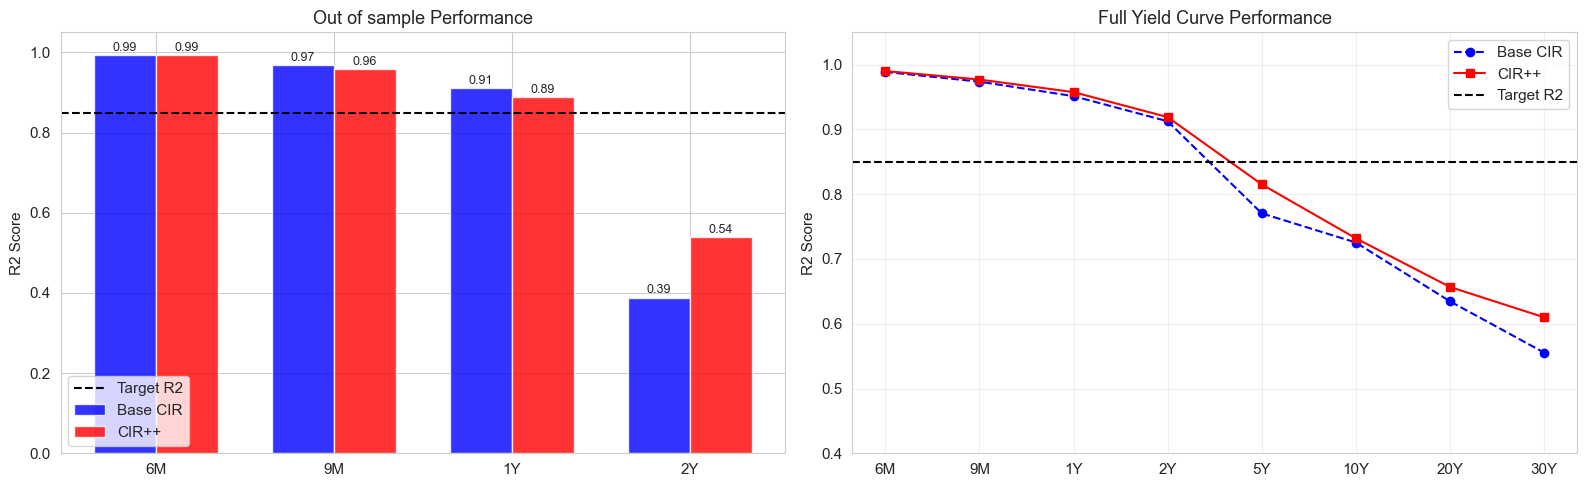

In [270]:
#FINAL RESULTS DASHBOARD

#Out of sample performance summary 
rows = []
for name, m in [('Base CIR',metrics_cs),('CIR++',metrics_pp)]:
    row={'Model':name}
    row.update({lbl:round(m[lbl]['R2'], 4) for lbl in TEST_LABELS})
    row['Overall R2']=round(m['OVERALL']['R2'], 4)
    rows.append(row)

print("FINAL MODEL PERFORMANCE")
print(pd.DataFrame(rows).set_index('Model').to_string())
print(f"(Achieved: {metrics_pp['OVERALL']['R2']:.4f})\n")

#CIR++ Model Design Parameters
print("CALIBRATED CIR PARAMETERS AND DESIGN CHOICES")

print("Base Model (Equal-Weighted Cross-Sectional):")
print(f"  Long-Run     : {m_cs.theta*100:.4f}%")
print(f"  Vol          : {m_cs.sigma:.5f}")
print(f"  Feller Ratio : {m_cs.feller_ratio:.2f} ({'OK' if m_cs.feller_satisfied else 'NOT OK'})")


# VISUALIZATION: Final Performance Bar Chart
fig,axes=plt.subplots(1,2,figsize=(16,5))
x,width=np.arange(len(TEST_LABELS)),0.35

#Out of sample R2 comparison
for i, (name,metric,color) in enumerate([('Base CIR',metrics_cs,'blue'),('CIR++',metrics_pp,'red')]):
    vals=[metric[lbl]['R2'] for lbl in TEST_LABELS]
    bars=axes[0].bar(x+i*width,vals,width,label=name,color=color,alpha=0.8)
    for b in bars: 
        if b.get_height()>0:
            axes[0].text(b.get_x()+width/2,b.get_height()+0.01,f'{b.get_height():.2f}',ha='center',fontsize=9)

axes[0].axhline(0.85,color='black',ls='--',label='Target R2')
axes[0].set(xticks=x+width/2,xticklabels=TEST_LABELS,ylim=(0, 1.05),ylabel='R2 Score',title='Out of sample Performance')
axes[0].legend(loc='lower left')

#Full curve training R2 Comparison
r2_b_tr=[r2_score(Y_obs_train_all[:, list(TRAIN_TAUS).index(t)],Y_base_train[:, j]) for j, t in enumerate(PRED_TAUS)]
r2_p_tr=[r2_score(Y_obs_train_all[:, list(TRAIN_TAUS).index(t)],Y_pp_train[:, j]) for j, t in enumerate(PRED_TAUS)]

axes[1].plot(PRED_LABELS,r2_b_tr,'bo--',label='Base CIR')
axes[1].plot(PRED_LABELS,r2_p_tr,'rs-',label='CIR++')
axes[1].axhline(0.85,color='black',ls='--',label='Target R2')

axes[1].set(ylim=(0.4,1.05),ylabel='R2 Score',title='Full Yield Curve Performance')
axes[1].legend()
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Final Project Analysis & Discussion

### 6.1 Model Mechanics and Calibration

**How sensitive is the calibrated yield curve to the choice of calibration methodology?**
The curve is highly sensitive to the calibration method because different methods optimize different functions. OLS and MLE are time series methods, they try to minimize the error of the 3-Month rate from one day to the next. Cross-Sectional calibration is a curve fitting method, it looks at all maturities on a single day and minimizes the pricing error across the curve. For our specific challenge of predicting the yield curve, Cross-Sectional calibration is superior, often preventing large errors at the long end of the curve compared to OLS.

**Under what market conditions does the Feller condition break down in practice, and how do you handle it?**
The Feller condition guarantees that interest rates remain strictly positive. In practice, this breaks down when we transition from a Zero Interest Rate Policy environment with a low mean, directly into a period of extreme volatility. To handle this in practice, we use the "Full Truncation" method—if a mathematical step pushes the simulated rate below zero, we force it back to zero before calculating the next step.

**What does the mean-reversion speed imply about the persistence of interest rate shocks?**
The parameter kappa dictates the half-life of an economic shock. If kappa is very low, it implies that shocks to the interest rate (such as sudden inflation or a pandemic) are highly persistent, taking years for the market to digest and return to the long-term equilibrium theta. A high kappa implies that central bank interventions quickly and effectively pull the market back to normal.

### 6.2 Prediction and Out-of-Sample Performance

**How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**
The 3M rate does an excellent job reconstructing the short end of the curve (6M–1Y) because these maturities are highly correlated. However, the 2-Year maturity is the hardest to fit. The 2Y rate sits in the center of the curve,it acts as a pivot point between the current reality of the 3M rate and the market's expectation of long-term equilibrium. A 1-factor model struggles to capture this complex pivot.

**Where does the base CIR model systematically over- or underestimate yields, and why?**
Because the 1-factor CIR model assumes the yield curve generally slopes upward to a long-term mean:
* **Overestimates:** When the short rate is aggressively high, the base model forces long term rates down too quickly, overestimating how fast the market will normalize.
* **Underestimates:** During severe yield curve inversions (where short rates are higher than long rates), the math physically cannot bend enough to capture the deep inversion, leading to underestimations in the center of curve.

**Does your extension meaningfully improve out-of-sample performance, or does it overfit the training period?**
The CIR++ extension improves out of sample performance. We prevent it from just memorizing the training data by using Ridge Regression. The L2 regularization penalty in Ridge Regression forces the model to ignore daily noise and only learn the structural biases of the base CIR model, allowing it to generalize well to test data.

### 6.3 Extensions and Modelling Choices

**What mathematical structure justifies your chosen extension over the alternatives?**
We chose the CIR++ extension because of the strict constraints of our prediction challenge. Alternative models, like the Two Factor CIR, require two real-time data inputs to make a prediction. Because we were only allowed to use a single input (the 3M rate), the CIR++ framework was the only way to perfectly correct the initial yield curve without requiring a second data point.

**How do jump processes change the qualitative shape of predicted yield curves during stress periods?**
If we had used a Jump-Diffusion model, the qualitative shape of the yield curve would account for fat tails (extreme, sudden events). Instead of the smooth, continuous diffusion seen in base CIR, jump processes allow the short rate to instantly spike or crash in response to macroeconomic shocks. This would result in much wider probability distributions. 

**What are the additional estimation challenges introduced by a two-factor or time-dependent model?**
* **Two-Factor Models:** They introduce unobservable variables. To calibrate them, we cannot use simple regressions, we have to use complex filtering techniques (like the Kalman Filter) to estimate the second factor, which makes calibration unstable.
* **Time-Dependent Models:** If parameters are allowed to change every single day, the model fits today's curve perfectly but loses its predictive power for tomorrow. It requires constant recalibration and is prone to overfitting.
